# 02 — Modeling, Optimization & Submission (F1-score)
Objectif : maximiser le **F1-score**, calibrer le **seuil de décision**, et produire `submission.csv` à partir de `data_test.csv`.

-> Test : conversion_data_test.csv
Résultats (F1 optimisé):
- logreg: F1=0.7767 | seuil=0.960
- gb: F1=0.7730 | seuil=0.435
- xgb: F1=0.7687 | seuil=0.423
- rf: F1=0.7246 | seuil=0.854
--> Meilleur modèle: logreg | F1=0.7767 | seuil=0.960
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     55080
           1       0.85      0.72      0.78      1836

    accuracy                           0.99     56916
   macro avg       0.92      0.86      0.88     56916
weighted avg       0.99      0.99      0.99     56916



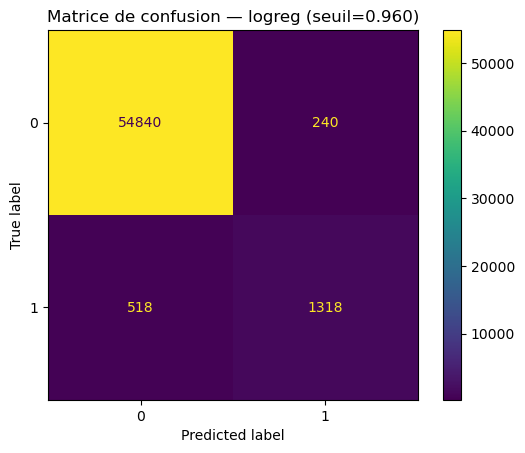

In [2]:
# --- Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from pprint import pprint

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier



TRAIN_FILE ='conversion_data_train.csv'
TEST_FILE  ='conversion_data_test.csv'

print("-> Test :", TEST_FILE)

df = pd.read_csv(TRAIN_FILE)

# Cible
TARGET='converted'

y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET])

# Cast automatiques
for col in X.select_dtypes(include='object').columns:
    try:
        X[col] = pd.to_numeric(X[col])
    except Exception:
        pass

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

# Split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_pipe = Pipeline([("scaler", StandardScaler(with_mean=False))])
cat_pipe = Pipeline([("ohe", OneHotEncoder(handle_unknown='ignore'))])

preproc = ColumnTransformer(
    [("num", num_pipe, num_cols),
     ("cat", cat_pipe, cat_cols)],
    remainder='drop',
    sparse_threshold=0.1
)

# --- Définir un set de modèles
models = {
    "logreg": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "rf": RandomForestClassifier(class_weight='balanced', n_estimators=400, random_state=42),
    "gb": GradientBoostingClassifier()
}

models["xgb"] = XGBClassifier(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

results = []
best_pipe = None
best_name = None
best_f1 = -1

for name, clf in models.items():
    pipe = Pipeline([("preproc", preproc), ("clf", clf)])
    pipe.fit(X_tr, y_tr)
    # Probabilités pour optimiser le seuil
    if hasattr(pipe.named_steps["clf"], "predict_proba"):
        proba = pipe.predict_proba(X_te)[:,1]
    else:
        # fallback via decision_function si dispo, sinon predictions binaires
        if hasattr(pipe.named_steps["clf"], "decision_function"):
            scores = pipe.decision_function(X_te)
            # Normalisation min-max pour approx proba
            proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
        else:
            proba = pipe.predict(X_te).astype(float)

    prec, rec, thr = precision_recall_curve(y_te, proba)
    f1s = 2*prec*rec/(prec+rec+1e-9)
    thr_for_max = thr[np.nanargmax(f1s[:-1])] if len(thr) > 0 else 0.5
    y_pred_opt = (proba >= thr_for_max).astype(int)
    f1_opt = f1_score(y_te, y_pred_opt)

    results.append((name, f1_opt, thr_for_max))
    if f1_opt > best_f1:
        best_f1, best_name, best_pipe, best_thr = f1_opt, name, pipe, thr_for_max

print("Résultats (F1 optimisé):")
for r in sorted(results, key=lambda x: x[1], reverse=True):
    print(f"- {r[0]}: F1={r[1]:.4f} | seuil={r[2]:.3f}")
print(f"--> Meilleur modèle: {best_name} | F1={best_f1:.4f} | seuil={best_thr:.3f}")

# Rapport + matrice de confusion
proba = best_pipe.predict_proba(X_te)[:,1] if hasattr(best_pipe.named_steps["clf"], "predict_proba") else None
if proba is None and hasattr(best_pipe.named_steps["clf"], "decision_function"):
    scores = best_pipe.named_steps["clf"].decision_function(X_te)
    proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
y_pred_opt = (proba >= best_thr).astype(int)
print(classification_report(y_te, y_pred_opt))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred_opt)).plot()
plt.title(f"Matrice de confusion — {best_name} (seuil={best_thr:.3f})")
plt.show()


## Optimisation supplémentaire (RandomizedSearchCV) sur le meilleur algo

In [3]:
search = None
if best_name == "rf":
    param_dist = {
        "clf__n_estimators": [300, 400, 600, 800],
        "clf__max_depth": [None, 6, 10, 14],
        "clf__min_samples_split": [2, 5, 10],
        "clf__min_samples_leaf": [1, 2, 4]
    }
elif best_name == "gb":
    param_dist = {
        "clf__n_estimators": [200, 400, 600],
        "clf__learning_rate": [0.02, 0.05, 0.1],
        "clf__max_depth": [2, 3, 4]
    }
elif best_name == "logreg":
    param_dist = {
        "clf__C": [0.1, 0.5, 1.0, 2.0, 5.0],
        "clf__penalty": ["l2"],
        "clf__solver": ["lbfgs", "liblinear"]
    }
elif best_name == "xgb":
    param_dist = {
        "clf__n_estimators": [400, 600, 900],
        "clf__max_depth": [4, 5, 6, 8],
        "clf__learning_rate": [0.03, 0.05, 0.1],
        "clf__subsample": [0.8, 0.9, 1.0],
        "clf__colsample_bytree": [0.8, 0.9, 1.0]
    }
else:
    param_dist = None

if param_dist is not None:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(
        estimator=best_pipe,
        param_distributions=param_dist,
        n_iter=20,
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    search.fit(X_tr, y_tr)
    print("Meilleurs hyperparamètres:")
    pprint(search.best_params_)
    tuned_pipe = search.best_estimator_
else:
    tuned_pipe = best_pipe

# Évaluer avec seuil optimisé sur l'ensemble de validation
if hasattr(tuned_pipe.named_steps["clf"], "predict_proba"):
    proba = tuned_pipe.predict_proba(X_te)[:,1]
else:
    if hasattr(tuned_pipe.named_steps["clf"], "decision_function"):
        scores = tuned_pipe.named_steps["clf"].decision_function(X_te)
        proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        proba = tuned_pipe.predict(X_te).astype(float)

from sklearn.metrics import precision_recall_curve
prec, rec, thr = precision_recall_curve(y_te, proba)
f1s = 2*prec*rec/(prec+rec+1e-9)
best_thr_tuned = thr[np.nanargmax(f1s[:-1])] if len(thr) > 0 else 0.5
y_pred_val = (proba >= best_thr_tuned).astype(int)
print(f"F1 (validation, seuil optimisé={best_thr_tuned:.3f}):", round(f1_score(y_te, y_pred_val), 4))


Fitting 5 folds for each of 10 candidates, totalling 50 fits


/home/burgovida21/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 10 is smaller than n_iter=20. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Meilleurs hyperparamètres:
{'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
F1 (validation, seuil optimisé=0.958): 0.7764


## Feature importance / Interprétation

In [4]:
import numpy as np
import pandas as pd

def get_feature_names(preproc, num_cols, cat_cols):
    # Reconstruire les noms des features après ColumnTransformer
    out = []
    # Numériques
    out += num_cols
    # Catégorielles (OHE)
    ohe = preproc.named_transformers_['cat'].named_steps['ohe']
    ohe_cols = ohe.get_feature_names_out(cat_cols).tolist()
    out += ohe_cols
    return out

feat_names = get_feature_names(tuned_pipe.named_steps['preproc'], num_cols, cat_cols)

importances = None
clf = tuned_pipe.named_steps['clf']
if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
elif hasattr(clf, "coef_"):
    coefs = clf.coef_[0] if clf.coef_.ndim > 1 else clf.coef_
    importances = np.abs(coefs)
else:
    importances = None

if importances is not None:
    fi = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False).head(25)
    display(fi)
else:
    print("Le modèle ne fournit pas directement des importances. Envisagez une permutation importance.")


,feature,importance
3,country_China,3.279220
2,total_pages_visited,2.501223
8,source_Direct,1.065651
9,source_Seo,0.908487
7,source_Ads,0.846204
1,new_user,0.752642
0,age,0.560487
4,country_Germany,0.386074
5,country_UK,0.178980
6,country_US,0.106176


## Génération de `submission.csv`

In [5]:
if TEST_FILE is None:
    print("⚠️ Aucun fichier test trouvé : submission non créée.")
else:
    df_test = pd.read_csv(TEST_FILE)

    # Déterminer la colonne ID si présente
    id_col = None
    for cand in ["id","ID","Id","user_id","row_id"]:
        if cand in df_test.columns:
            id_col = cand
            break

    # Aligner colonnes avec l'entraînement
    X_test = df_test.copy()
    # Supprimer la cible si par erreur présente
    for c in [TARGET, TARGET.upper()]:
        if c in X_test.columns:
            X_test = X_test.drop(columns=[c])

    # Cast automatiques cohérents
    for col in X_test.select_dtypes(include='object').columns:
        try:
            X_test[col] = pd.to_numeric(X_test[col])
        except Exception:
            pass

    # Prédictions probabilistes + seuil optimisé
    if hasattr(tuned_pipe.named_steps["clf"], "predict_proba"):
        proba_test = tuned_pipe.predict_proba(X_test)[:,1]
    else:
        if hasattr(tuned_pipe.named_steps["clf"], "decision_function"):
            scores = tuned_pipe.named_steps["clf"].decision_function(X_test)
            proba_test = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
        else:
            proba_test = tuned_pipe.predict(X_test).astype(float)

    y_pred_test = (proba_test >= best_thr_tuned).astype(int)

    sub = pd.DataFrame({
        "id": df_test[id_col].values if id_col is not None else np.arange(len(df_test)),
        "prediction": y_pred_test
    })
    SUB_PATH = Path("submission.csv")
    sub.to_csv(SUB_PATH, index=False)
    print(f"✅ Submission sauvegardée: {SUB_PATH.resolve()}")


✅ Submission sauvegardée: /home/burgovida21/Bureau/CDSD_Certification_Projets/Projet 5 - Supervised ML - Conversion Rate Challenge/submission.csv


### Check rapide de la distribution de prédictions

In [6]:

sub['prediction'].value_counts(normalize=True)


prediction
0    0.972201
1    0.027799
Name: proportion, dtype: float64